# Comparing Data Sets.
____

In [1]:
from pathlib import Path
from microlive.imports import *
from microlive import microscopy as mi
current_dir = Path().resolve()
parent_dir = current_dir.parents[1]
main_dir = Path().resolve().parent
one_drive_dir = mi.Utilities.get_one_drive_dir()
import sys
repo_root = Path().resolve().parents[1]  # Go up to cof_paper/
sys.path.insert(0, str(repo_root))

import utilities as ld
importlib.reload(ld)


<module 'utilities' from '/Users/nzlab-la/Desktop/cof_paper/utilities/__init__.py'>

## Loading data and strings for subclassification
___

In [ ]:
# Loading data
dataframes_dir = Path('/Volumes/Luis_DRIVE/CoF Manuscript LIFs/Fig 3_LIF files/Analysis')

# Average Folder Substrings

list_folder_substring_to_avoid = None


save_dir = current_dir.joinpath('results')
save_dir.mkdir(parents=True, exist_ok=True)

# Individual day Folder Substrings
plot_individual_days = False

list_folder_substrings, list_names = ld.get_folder_substrings_and_names(
    dataframes_dir, 
    process_individual_days=plot_individual_days,
)
print(list_folder_substrings)
print(list_names)





Found 3 plasmids in 119 folders
  pRS027: 3 experiment(s)
  pRS032: 3 experiment(s)
  pNZ381: 2 experiment(s)
['pRS027', 'pRS032', 'pNZ381']
['4sfGFP-2mCh', '4GFPuv-2mCh', '6mCh']


## Loading the data
____

In [22]:
data_dict = ld.aggregate_folder_data(dataframes_dir,list_folder_substrings,
            list_folder_substring_to_avoid,list_folder_substring_second_condition=None,
            show_file_names=True, verbose= False)

Loaded results_20250429 37C pRS027_012_JF646_6hr tfx_Series001 (2 channels)
Loaded results_20250501 37C pRS027_012_JF646_6hr tfx_Series001 (2 channels)
Loaded results_20250505 37C pRS027_012_JF646_6hr tfx_Series001 (2 channels)
Loaded results_20250429 37C pRS027_012_JF646_6hr tfx_Series002 (2 channels)
Loaded results_20250501 37C pRS027_012_JF646_6hr tfx_Series002 (2 channels)
Loaded results_20250505 37C pRS027_012_JF646_6hr tfx_Series002 (2 channels)
Loaded results_20250429 37C pRS027_012_JF646_6hr tfx_Series003 (2 channels)
Loaded results_20250501 37C pRS027_012_JF646_6hr tfx_Series003 (2 channels)
Loaded results_20250505 37C pRS027_012_JF646_6hr tfx_Series003 (2 channels)
Loaded results_20250429 37C pRS027_012_JF646_6hr tfx_Series004 (2 channels)
Loaded results_20250501 37C pRS027_012_JF646_6hr tfx_Series004 (2 channels)
Loaded results_20250429 37C pRS027_012_JF646_6hr tfx_Series005 (2 channels)
Loaded results_20250501 37C pRS027_012_JF646_6hr tfx_Series005 (2 channels)
Loaded resul

## Plotting Configuration
___

In [23]:
# ── Plotting Configuration ─────────────────────────────────
PLOT_CONFIG = dict(
    figsize       = (5, 4),
    tick_size     = 10,
    swarm_color   = 'black',
    show_stats    = False,
    only_significant = True,
    max_percentile_significance = 99.5,
)

SAVE_DIR = save_dir  # Defined in data config above; set to None to skip saving


## Plotting data
___

In [24]:
for key in data_dict.keys():
    print(key)


directories
int_ch_0
int_ch_1
snr_ch_0
snr_ch_1
spot_size_ch_0
spot_size_ch_1
total_spot_int_ch_0
total_spot_int_ch_1
spot_amplitude_ch_0
spot_amplitude_ch_1
spot_sigma_ch_0
spot_sigma_ch_1
number_spots
frames
number_of_color_channels
average_number_spots
efficiency_ml
efficiency_manual


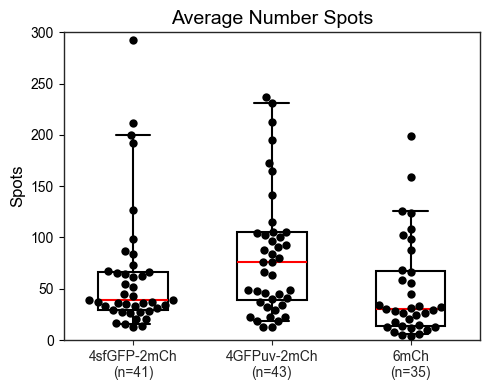

<Axes: title={'center': 'Average Number Spots'}, ylabel='Spots'>

In [25]:
ld.plot_swarm_plot(
    data_dict['average_number_spots'], list_names,
    y_label='Spots',
    title='Average Number Spots',
    y_lim=(0, 300),
    plot_name='avg_spots',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


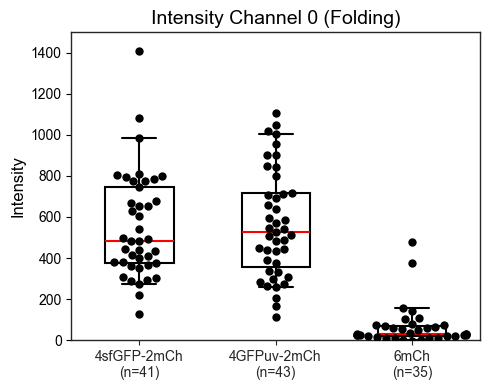

<Axes: title={'center': 'Intensity Channel 0 (Folding)'}, ylabel='Intensity'>

In [26]:
ld.plot_swarm_plot(
    data_dict['int_ch_0'], list_names,
    y_label='Intensity',
    title='Intensity Channel 0 (Folding)',
    y_lim=(0, 1500),
    plot_name='int_ch0',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


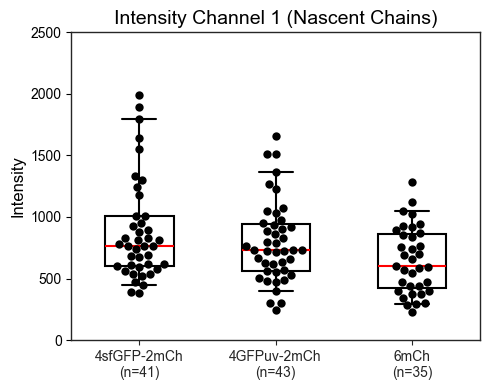

<Axes: title={'center': 'Intensity Channel 1 (Nascent Chains)'}, ylabel='Intensity'>

In [27]:
ld.plot_swarm_plot(
    data_dict['int_ch_1'], list_names,
    y_label='Intensity',
    title='Intensity Channel 1 (Nascent Chains)',
    y_lim=(0, 2500),
    plot_name='int_ch1',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


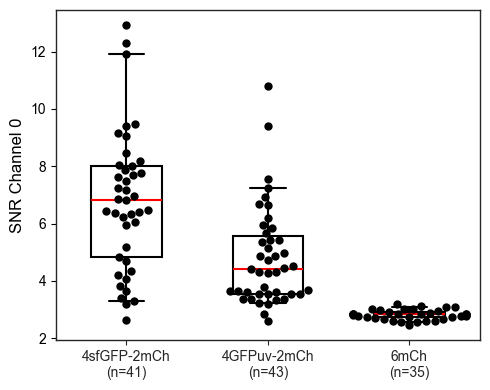

<Axes: ylabel='SNR Channel 0'>

In [28]:
ld.plot_swarm_plot(
    data_dict['snr_ch_0'], list_names,
    y_label='SNR Channel 0',
    plot_name='snr_ch0',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


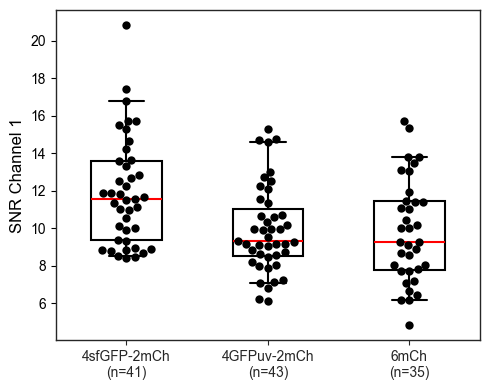

<Axes: ylabel='SNR Channel 1'>

In [29]:
ld.plot_swarm_plot(
    data_dict['snr_ch_1'], list_names,
    y_label='SNR Channel 1',
    plot_name='snr_ch1',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


## Calculating Folding Efficiency using ML method

___

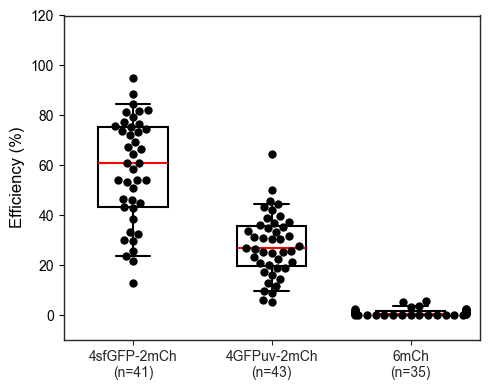

<Axes: ylabel='Efficiency (%)'>

In [30]:
ld.plot_swarm_plot(
    data_dict['efficiency_ml'], list_names,
    y_label='Efficiency (%)',
    y_lim=(-10, 120),
    plot_name='efficiency_ml',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


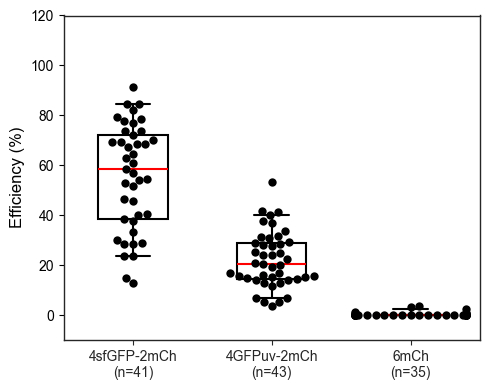

<Axes: ylabel='Efficiency (%)'>

In [31]:
ld.plot_swarm_plot(
    data_dict['efficiency_manual'], list_names,
    y_label='Efficiency (%)',
    y_lim=(-10, 120),
    plot_name='efficiency_new',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


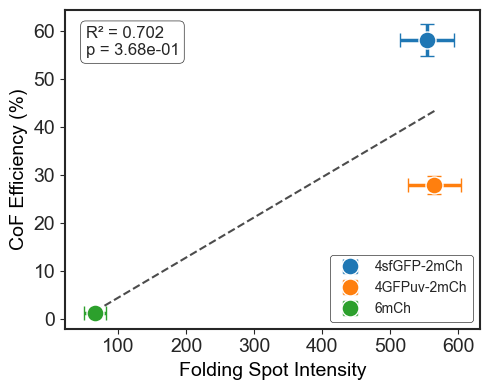

<Axes: xlabel='Folding Spot Intensity', ylabel='CoF Efficiency (%)'>

In [32]:
ld.plot_efficiency_vs_intensity_scatter_means(
    data_dict, list_names,
    x_label='Folding Spot Intensity',
    y_label='CoF Efficiency (%)',
    figsize=PLOT_CONFIG['figsize'],
    tick_size=PLOT_CONFIG['tick_size'],
    marker_size=150,
    save_dir=SAVE_DIR,
    plot_name='intensity_efficiency',
)


In [84]:
from matplotlib.patches import Ellipse
from scipy import stats

def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    """Draw an n_std confidence ellipse around the mean of x and y."""
    if len(x) < 3:
        return
    cov = np.cov(x, y)
    vals, vecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(*vecs[:, -1][::-1]))
    w, h = 2 * n_std * np.sqrt(vals)
    ellipse = Ellipse(xy=(np.mean(x), np.mean(y)), width=w, height=h, angle=angle, **kwargs)
    ax.add_patch(ellipse)

def plot_efficiency_vs_intensity_hexbin(
    data_dict, condition_labels, x_label="Spot Intensity", y_label="CoF Efficiency (%)",
    title="", figsize=(8, 6), tick_size=12, marker_size=20, marker_alpha=0.5, kde_alpha =0.12,
    show_condition_means=False, mean_marker_size=100, show_marginals=False,
    show_kde=True, show_ellipse=False, ellipse_std=2.0,
    show_regression=False, x_lim =None, y_lim = None, 
    marginal_kws=None, save_dir=None, plot_name='efficiency_vs_intensity_hexbin',
):
    """Create joint scatter plot with marginal distributions, colored per condition.

    Parameters
    ----------
    data_dict : dict
        Dictionary with keys 'int_ch_0' and 'efficiency_ml'.
    condition_labels : list of str
        Labels for each condition.
    x_label, y_label : str
        Axis labels.
    title : str
        Plot title.
    figsize : tuple
        Figure size (width, height).
    tick_size : int
        Base tick label font size.
    marker_size : int
        Size of individual scatter dots.
    marker_alpha : float
        Transparency of scatter dots.
    show_condition_means : bool
        If True, overlay per-condition mean markers with error bars.
    mean_marker_size : int
        Marker size for condition means.
    show_marginals : bool
        If True, show marginal histograms on both axes.
    show_kde : bool
        If True, overlay filled KDE contours per condition.
    show_ellipse : bool
        If True, draw confidence ellipses around each condition.
    ellipse_std : float
        Number of standard deviations for the confidence ellipse (2.0 ≈ 95%).
    show_regression : bool
        If True, show linear regression line with R² and p-value.
    marginal_kws : dict or None
        Extra keyword arguments for marginal histograms.
    save_dir : str or None
        Directory to save the figure (PNG + SVG at 600 dpi).
    plot_name : str
        Base filename for saved figures.

    Returns
    -------
    g : seaborn.JointGrid
        The JointGrid object for further customization.
    """
    sns.set_style("ticks")
    mpl.rcParams['font.family'] = 'Arial'
    mpl.rcParams['text.color'] = 'black'
    mpl.rcParams['axes.labelcolor'] = 'black'
    mpl.rcParams['xtick.color'] = 'black'
    mpl.rcParams['ytick.color'] = 'black'

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
              '#8c564b', '#e377c2', '#17becf', '#bcbd22', '#7f7f7f']
    markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', 'h', '<']

    # --- Collect per-cell data, separated by condition ---
    condition_data = []
    condition_means = []

    for cond_idx, label in enumerate(condition_labels):
        int_data = data_dict['int_ch_0'][cond_idx]
        eff_data = data_dict['efficiency_ml'][cond_idx]
        if int_data is None or eff_data is None:
            continue
        cell_int, cell_eff = [], []
        for cell_idx in range(len(int_data)):
            intensities = np.asarray(int_data[cell_idx]).flatten()
            intensities = intensities[~np.isnan(intensities)]
            if len(intensities) == 0 or cell_idx >= len(eff_data) or np.isnan(eff_data[cell_idx]):
                continue
            cell_int.append(np.nanmean(intensities))
            cell_eff.append(eff_data[cell_idx])
        if not cell_int:
            continue

        color = colors[cond_idx % len(colors)]
        marker = markers[cond_idx % len(markers)]
        condition_data.append((np.array(cell_int), np.array(cell_eff), label, color, marker))

        n = len(cell_int)
        condition_means.append((
            np.mean(cell_int), np.std(cell_int) / np.sqrt(n),
            np.mean(cell_eff), np.std(cell_eff) / np.sqrt(n),
            label, color,
        ))

    if not condition_data:
        print("No valid data to plot.")
        return None

    # --- Build JointGrid manually ---
    g = sns.JointGrid(height=figsize[1], ratio=5)
    ax = g.ax_joint

    # --- KDE contours per condition ---
    if show_kde:
        for x_arr, y_arr, label, color, marker in condition_data:
            if len(x_arr) >= 3:
                sns.kdeplot(x=x_arr, y=y_arr, ax=ax, color=color, fill=True,
                            levels=3, alpha=0.2, linewidths=0.5)

    # --- Confidence ellipses ---
    if show_ellipse:
        for x_arr, y_arr, label, color, marker in condition_data:
            confidence_ellipse(x_arr, y_arr, ax, n_std=ellipse_std,
                               facecolor=color, alpha=kde_alpha, edgecolor=color, linewidth=2)

    # --- Scatter per condition ---
    for x_arr, y_arr, label, color, marker in condition_data:
        ax.scatter(x_arr, y_arr, c=color, s=marker_size, alpha=marker_alpha,
                   marker=marker, label=label, edgecolors='white', linewidths=0.3, zorder=2)

    # --- Marginal histograms ---
    if show_marginals:
        _marginal_kws = dict(bins=30, alpha=0.5, edgecolor='white', linewidth=0.5)
        if marginal_kws is not None:
            _marginal_kws.update(marginal_kws)
        for x_arr, y_arr, label, color, marker in condition_data:
            g.ax_marg_x.hist(x_arr, color=color, **_marginal_kws)
            g.ax_marg_y.hist(y_arr, color=color, orientation='horizontal', **_marginal_kws)
    else:
        g.ax_marg_x.set_visible(False)
        g.ax_marg_y.set_visible(False)

    # --- Condition means with error bars ---
    if show_condition_means and condition_means:
        for mean_int, sem_int, mean_eff, sem_eff, label, color in condition_means:
            ax.errorbar(
                mean_int, mean_eff, xerr=sem_int, yerr=sem_eff, fmt='o',
                color=color, markersize=np.sqrt(mean_marker_size), capsize=5,
                capthick=2.5, elinewidth=2.5,
                markeredgecolor='white', markeredgewidth=1, zorder=10,
            )

    # --- Linear regression across all pooled data ---
    if show_regression:
        all_int = np.concatenate([x for x, y, l, c, m in condition_data])
        all_eff = np.concatenate([y for x, y, l, c, m in condition_data])
        if len(all_int) >= 2:
            slope, intercept, r_value, p_value, _ = stats.linregress(all_int, all_eff)
            x_line = np.linspace(all_int.min(), all_int.max(), 100)
            ax.plot(x_line, slope * x_line + intercept, 'k--', lw=1.5, alpha=0.7)
            ax.text(
                0.05, 0.95, f'R² = {r_value**2:.3f}\np = {p_value:.2e}',
                transform=ax.transAxes, fontsize=tick_size + 2, va='top',
                fontname="Arial",
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black'),
            )

    # --- Styling ---
    ax.set_xlabel(x_label, fontsize=tick_size + 4, fontname="Arial", color='black')
    ax.set_ylabel(y_label, fontsize=tick_size + 4, fontname="Arial", color='black')
    ax.tick_params(labelsize=tick_size + 4)
    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, 1.15),
        ncol=len(condition_data),
        fontsize=tick_size,
        frameon=True,
        facecolor='white',
        edgecolor='black',
        prop={'family': 'Arial'}, 
        labelcolor='black', 
    )
    if x_lim is not None:
        ax.set_xlim(x_lim)
    if y_lim is not None:
        ax.set_ylim(y_lim)
    if title:
        g.figure.suptitle(title, fontsize=tick_size + 4, fontname="Arial", color='black', y=1.02)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
    g.figure.tight_layout()

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        g.figure.savefig(save_dir / f"{plot_name}.png", dpi=600, bbox_inches='tight')
        g.figure.savefig(save_dir / f"{plot_name}.svg", dpi=600, bbox_inches='tight')
    plt.show()
    return g


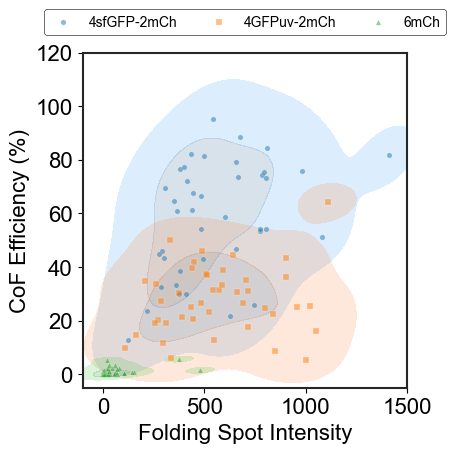

In [89]:
plot_efficiency_vs_intensity_hexbin(
    data_dict, list_names,
    show_condition_means=False,
    tick_size=12,
    figsize=(5, 5),
    marker_size=15,
    marker_alpha=0.5,
    kde_alpha=0.001,
    x_lim=(-100, 1500), y_lim=(-5, 120),
    show_regression=False, 
    save_dir=SAVE_DIR,
    x_label = 'Folding Spot Intensity',
    y_label = 'CoF Efficiency (%)',
)
